# WoundSense - Exploracao visual e qualidade das imagens (WoundsDB, unprocessed)

Este notebook foca em: visualizar as imagens de varios casos (foto, termica, estereo, mascara), checar a qualidade tecnica das aquisicoes (nitidez, exposicao, resolucao, consistencia entre arquivos) e inspecionar mais de perto a regiao da ferida. Complementa o notebook de caracterizacao do dataset.

## 1. Setup: baixar e extrair o dataset

In [ ]:
!pip install gdown -q
!gdown --fuzzy "https://drive.google.com/file/d/1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa/view?usp=sharing" -O patients.zip
!gdown --fuzzy "https://drive.google.com/file/d/19szG7ilU7ov21-ox5kolH2nJpVo0pTdI/view?usp=sharing" -O description.csv
!apt-get -qq install -y p7zip-full

Downloading...
From (original): https://drive.google.com/uc?id=1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa
From (redirected): https://drive.google.com/uc?id=1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa&confirm=t&uuid=aacc9a02-6d0b-4246-a1e3-b3ef5fd57eb6
To: /content/patients.zip
100% 3.69G/3.69G [01:00<00:00, 61.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=19szG7ilU7ov21-ox5kolH2nJpVo0pTdI
To: /content/description.csv
100% 20.9k/20.9k [00:00<00:00, 52.2MB/s]


In [ ]:
!7z x "patients.zip" -o"/content/patients_unprocessed" -y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 3689726338 bytes (3519 MiB)

Extracting archive: patients.zip
 55% 4096 Open              --
Path = patients.zip
Type = zip
Physical Size = 3689726338

  0%      0% 16 - patients/patients/case_1/day_1/calib/scene_2/photo.jpg                                                                  0% 26 - patients/patients/case_1/day_1/data/scene_1/photo.jpg                                                                 0% 45 - patients/pa

In [ ]:
from pathlib import Path

DATA_DIR = Path("/content/patients_unprocessed") / "patients" / "patients"
DESCRIPTION_CSV = "description.csv"
print(sorted(p.name for p in DATA_DIR.iterdir())[:10])

['case_1', 'case_10', 'case_11', 'case_12', 'case_13', 'case_14', 'case_15', 'case_16', 'case_17', 'case_18']


## 2. Imports e carregamento do csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

plt.rcParams["figure.figsize"] = (12, 4)

df = pd.read_csv(DESCRIPTION_CSV)
df.columns = [c.strip() for c in df.columns]
df["case"] = df["Path to files"].str.extract(r"case_(\d+)")
df["day"] = df["Path to files"].str.extract(r"day_(\d+)").astype(int)
df["scene"] = df["Path to files"].str.extract(r"scene_(\d+)")

venous = df[df["Wound aetiology"].isin(["Venous ulcers", "Venous insufficiency"])].reset_index(drop=True)
print(f"Subgrupo venoso: {len(venous)} cenas de {venous['case'].nunique()} pacientes")

Subgrupo venoso: 124 cenas de 31 pacientes


In [ ]:
def scene_folder(row, base=DATA_DIR):
    return base / f"case_{row['case']}" / f"day_{row['day']}" / "data" / f"scene_{row['scene']}"

def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def load_gray(path):
    return np.array(Image.open(path).convert("L"))

## 3. Visualizacao geral: foto, termica, estereo e mascara de varios pacientes

Mostra uma grade grande com varios casos diferentes, para ter uma visao ampla da variabilidade visual do subgrupo (angulos de captura, iluminacao, tamanho e aspecto das feridas).

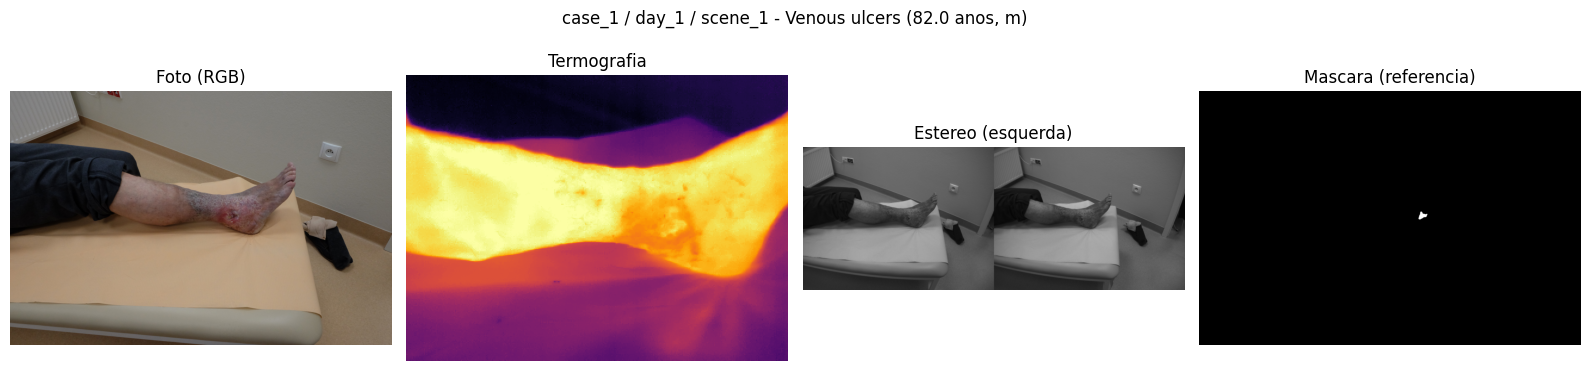

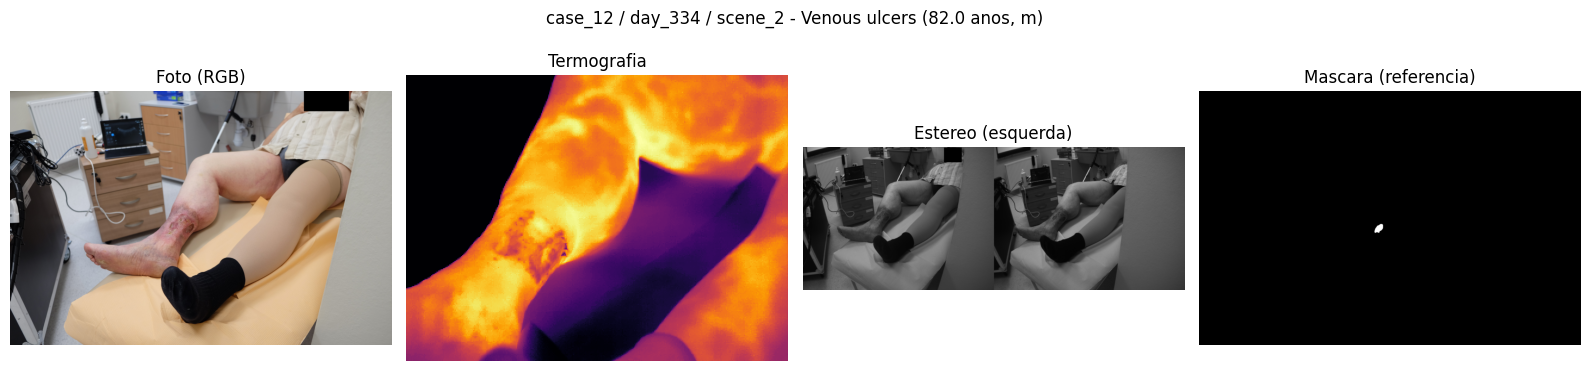

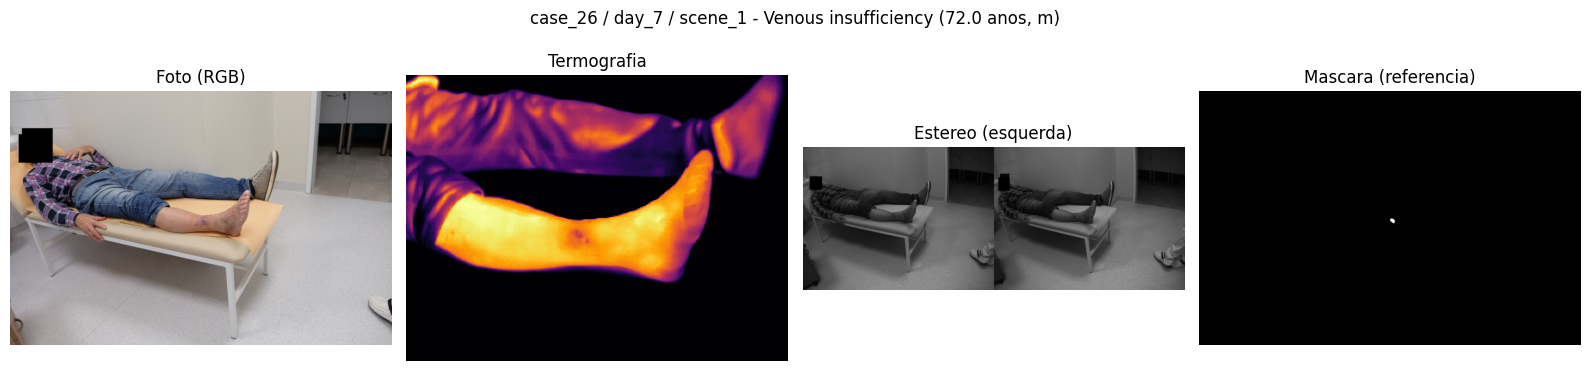

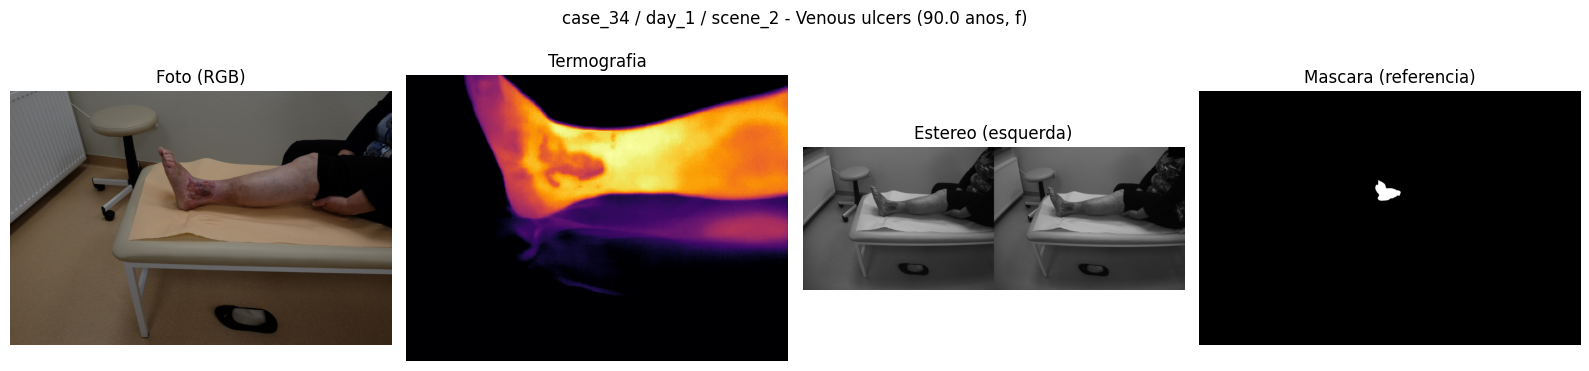

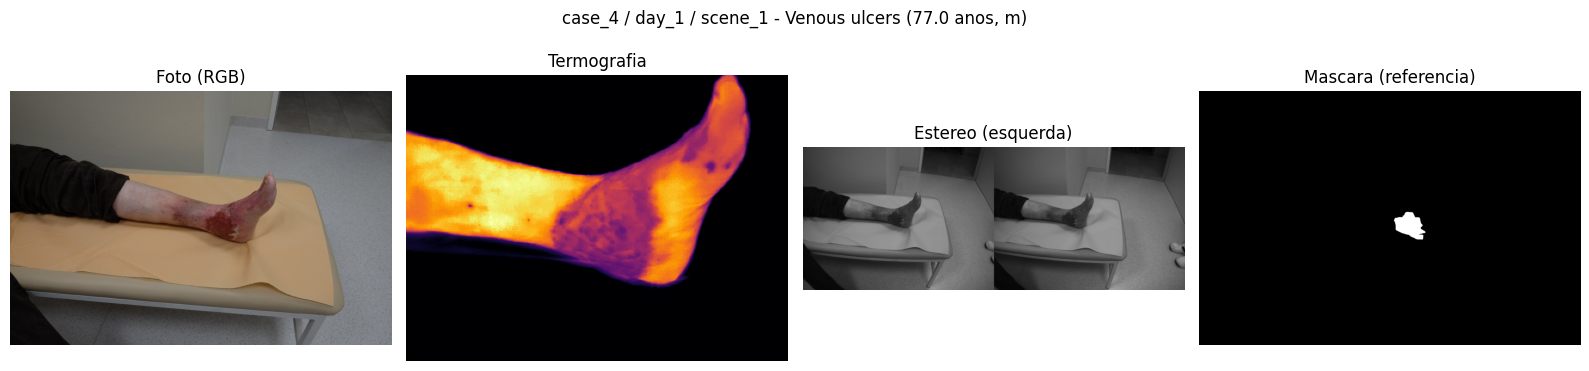

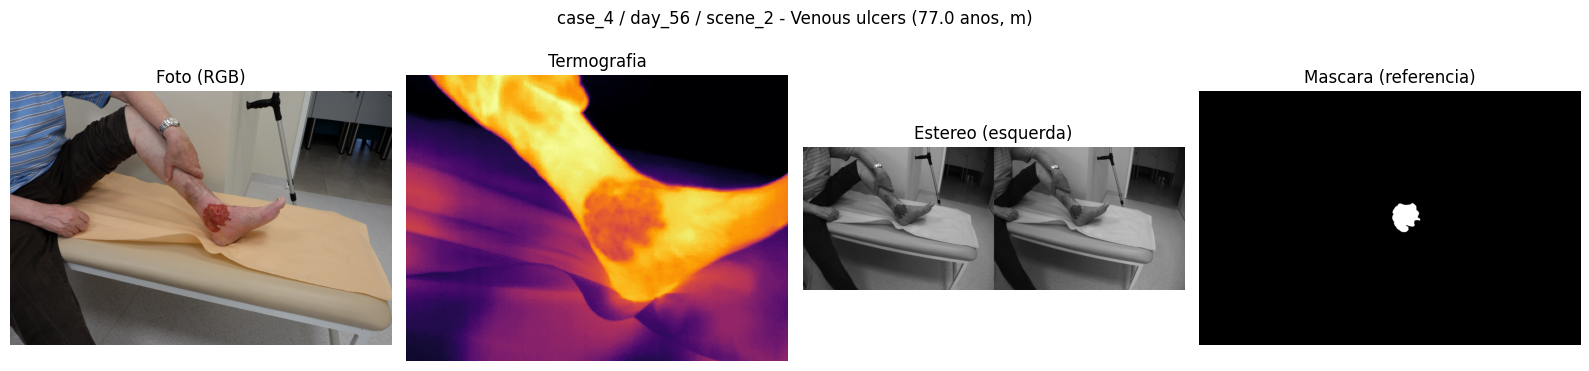

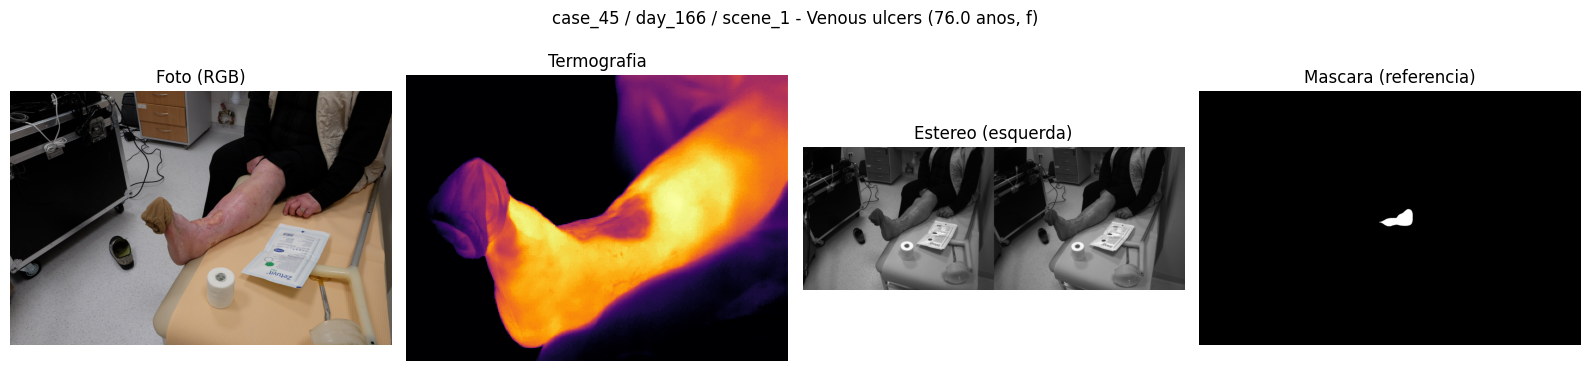

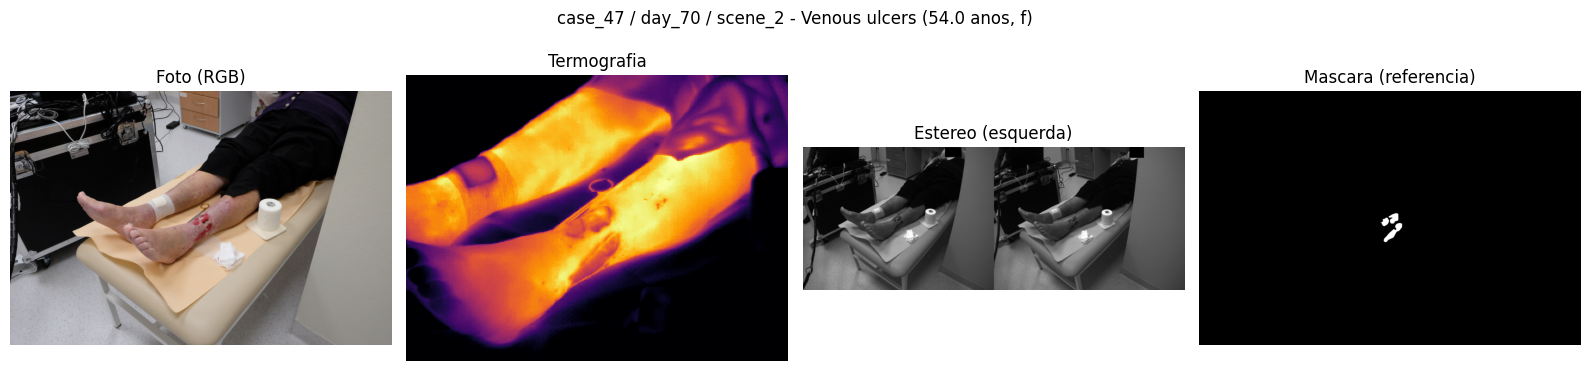

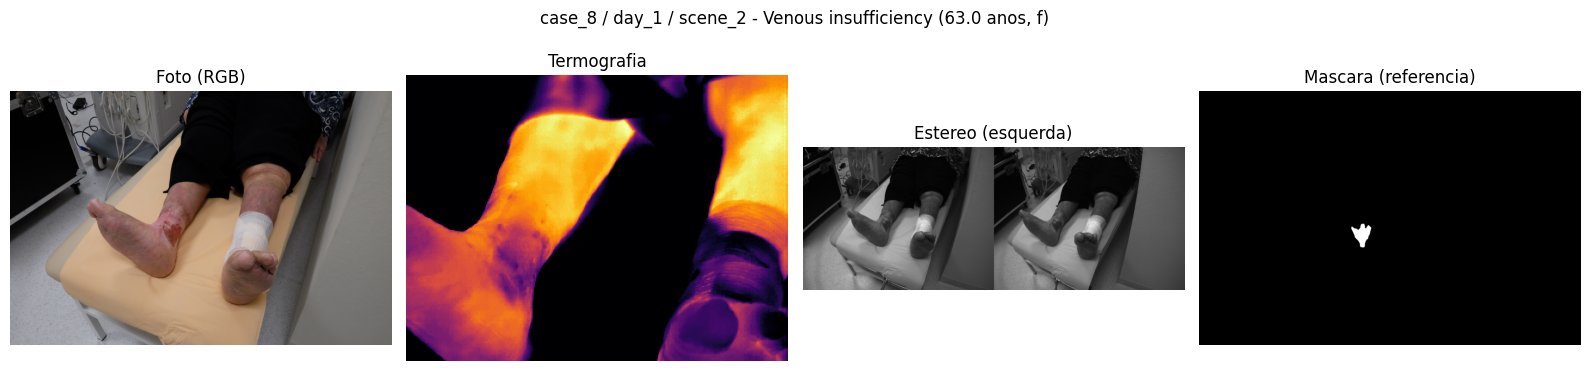

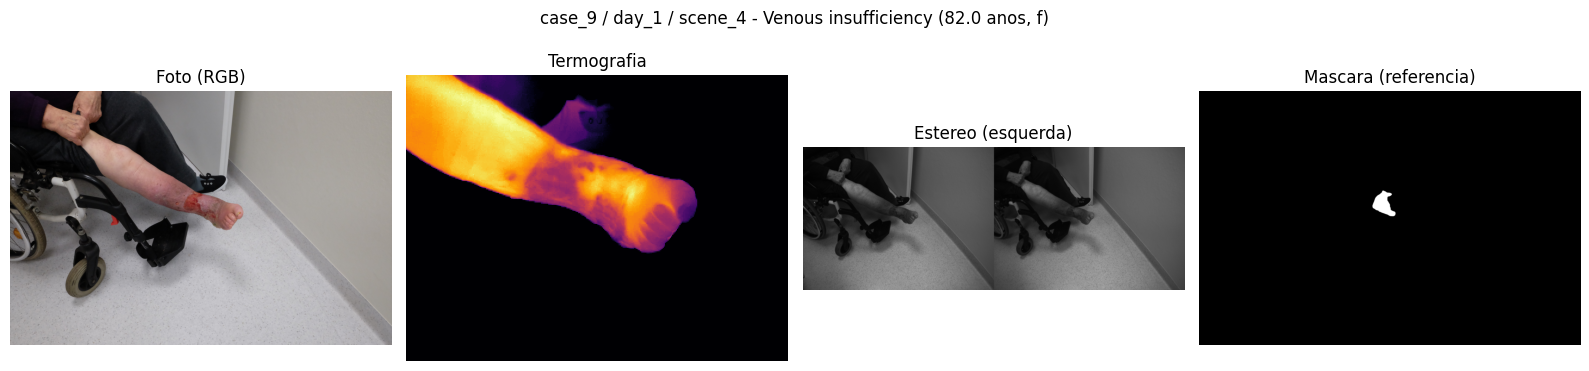

In [ ]:
def show_case_full(row, base=DATA_DIR):
    folder = scene_folder(row, base)
    photo = load_rgb(folder / "photo.jpg")
    thermal = load_gray(folder / "thermal.png")
    stereo_l = load_rgb(folder / "stereo_l.png")
    mask = load_gray(folder / "mask.png")

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(photo); axs[0].set_title("Foto (RGB)")
    axs[1].imshow(thermal, cmap="inferno"); axs[1].set_title("Termografia")
    axs[2].imshow(stereo_l); axs[2].set_title("Estereo (esquerda)")
    axs[3].imshow(mask, cmap="gray"); axs[3].set_title("Mascara (referencia)")
    for ax in axs:
        ax.axis("off")
    fig.suptitle(f"case_{row['case']} / day_{row['day']} / scene_{row['scene']} - {row['Wound aetiology']} "
                 f"({row['Age [year]']} anos, {row['Sex']})")
    plt.tight_layout()
    plt.show()

# mostra ate 10 casos diferentes do subgrupo venoso, espalhados ao longo da lista
sample_idxs = np.linspace(0, len(venous) - 1, 10).astype(int)
for idx in sample_idxs:
    show_case_full(venous.iloc[idx])

## 4. Mascara sobreposta na foto (conferencia visual do delineamento)

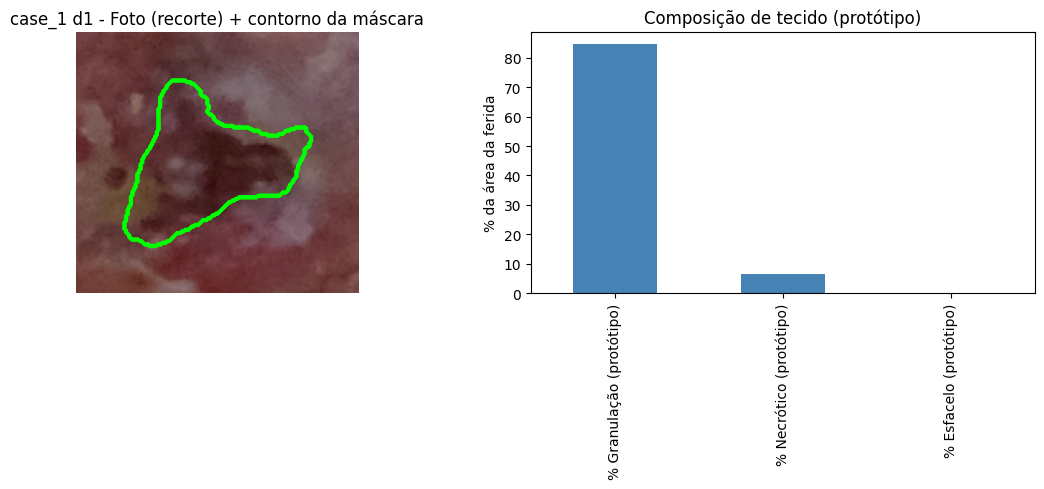

In [ ]:
import matplotlib.colors as mcolors

row = venous.iloc[0]
folder = scene_folder(row)
photo = load_rgb(folder / "photo.jpg")
mask = load_gray(folder / "mask.png")

def tissue_composition(photo_rgb, mask):
    photo_norm = photo_rgb / 255.0
    wound_pixels = photo_norm[mask > 0]

    hsv = mcolors.rgb_to_hsv(wound_pixels)
    hue_deg = hsv[:, 0] * 360
    sat = hsv[:, 1]
    val = hsv[:, 2]

    granulacao = ((hue_deg < 20) | (hue_deg > 340)) & (sat > 0.3)
    necrotico = val < 0.25
    esfacelo = (hue_deg > 40) & (hue_deg < 70) & (sat > 0.2)

    return pd.Series({
        "% Granulação (protótipo)": round(granulacao.mean() * 100, 1),
        "% Necrótico (protótipo)": round(necrotico.mean() * 100, 1),
        "% Esfacelo (protótipo)": round(esfacelo.mean() * 100, 1),
    })

composicao = tissue_composition(photo, mask)

crop = crop_to_mask(photo, mask, padding=30)
ys, xs = np.where(mask > 0)
x0, x1 = max(xs.min() - 30, 0), min(xs.max() + 30, photo.shape[1])
y0, y1 = max(ys.min() - 30, 0), min(ys.max() + 30, photo.shape[0])
mask_crop = mask[y0:y1, x0:x1]

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

axs[0].imshow(crop)
axs[0].contour(mask_crop, colors="lime", linewidths=2)
axs[0].set_title(f"case_{row['case']} d{row['day']} - Foto (recorte) + contorno da máscara")
axs[0].axis("off")

composicao.plot(kind="bar", ax=axs[1], color="steelblue")
axs[1].set_title("Composição de tecido (protótipo)")
axs[1].set_ylabel("% da área da ferida")
axs[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

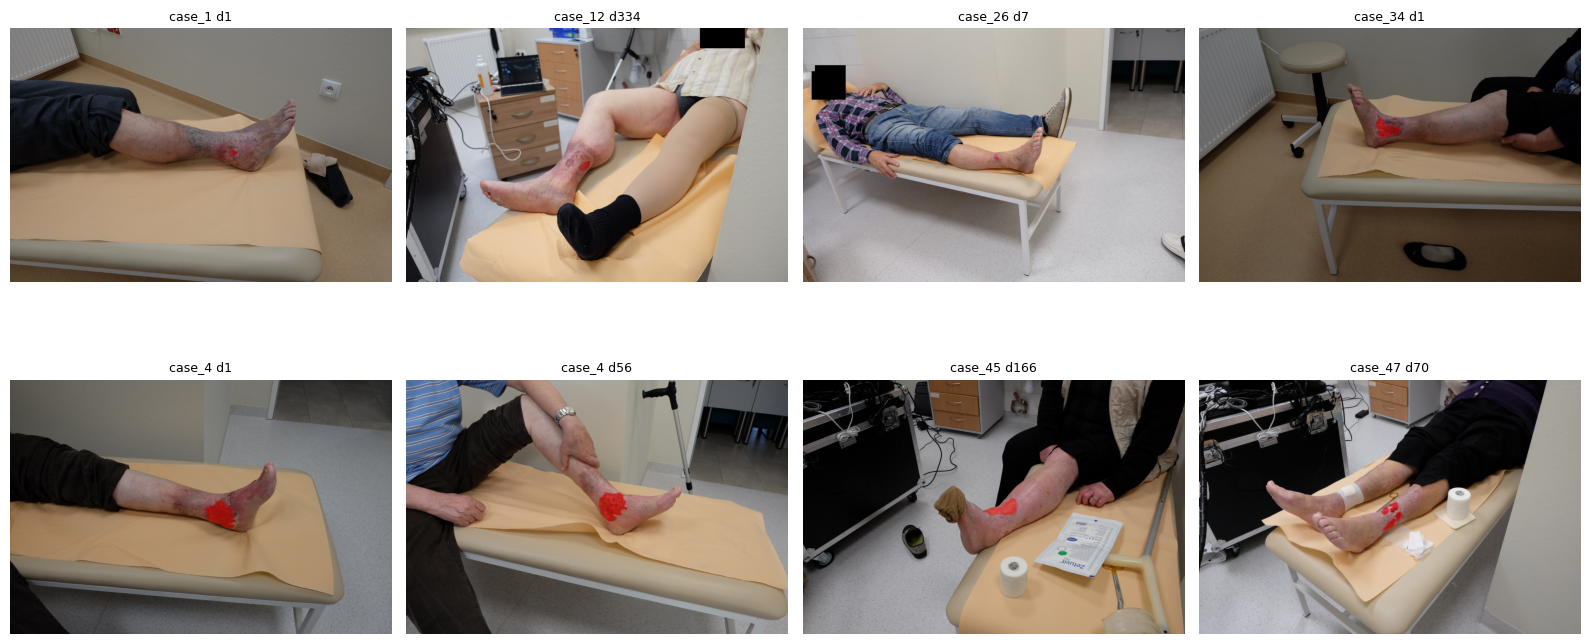

In [ ]:
def overlay_mask(img_rgb, mask, color=(255, 0, 0), alpha=0.4):
    mask_bin = mask > 0
    overlay = img_rgb.copy()
    overlay[mask_bin] = color
    return cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axs.ravel(), sample_idxs[:8]):
    row = venous.iloc[idx]
    folder = scene_folder(row)
    photo = load_rgb(folder / "photo.jpg")
    mask = load_gray(folder / "mask.png")
    ax.imshow(overlay_mask(photo, mask))
    ax.set_title(f"case_{row['case']} d{row['day']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Acompanhamento longitudinal: a mesma ferida em dias diferentes

Para os pacientes com mais de uma visita, mostra a evolucao visual da ferida ao longo do tempo.

Pacientes venosos com mais de um dia: ['11', '12', '13', '23', '26', '36', '39', '4', '45', '46', '47', '8']


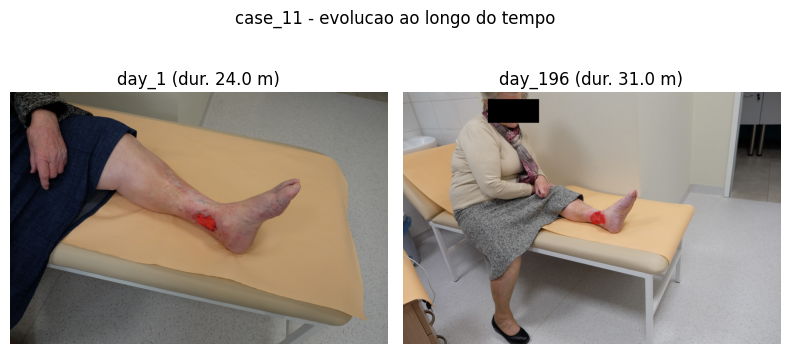

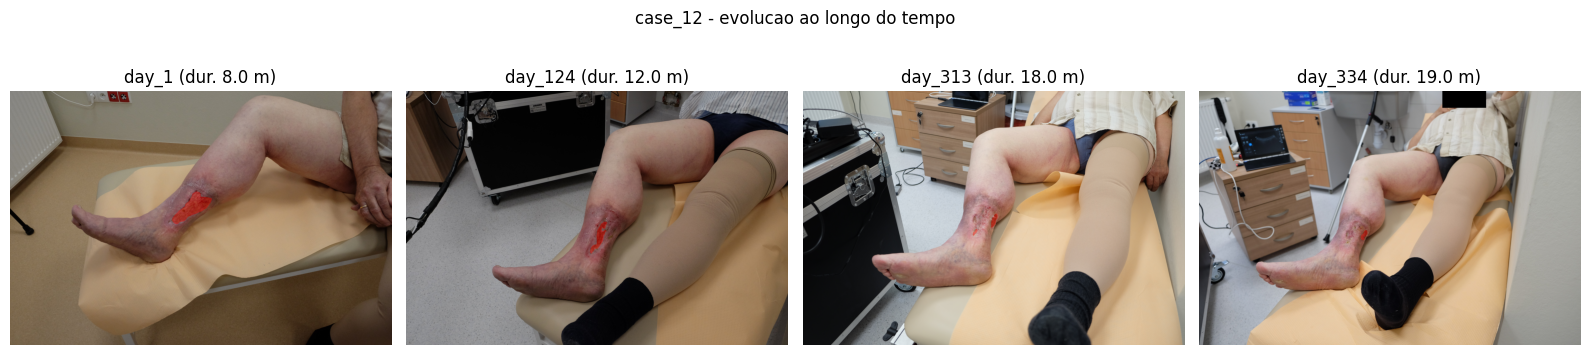

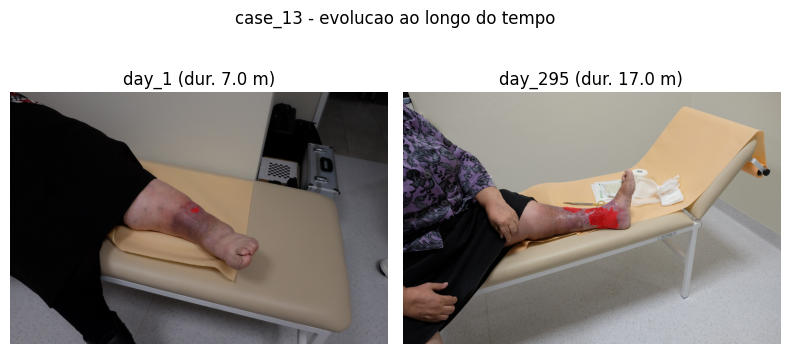

In [ ]:
multi_day_cases = venous.groupby("case")["day"].nunique()
multi_day_cases = multi_day_cases[multi_day_cases > 1].index.tolist()
print("Pacientes venosos com mais de um dia:", multi_day_cases)

for case_id in multi_day_cases[:3]:
    rows = venous[(venous["case"] == case_id) & (venous["scene"] == "1")].sort_values("day")
    n = len(rows)
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axs = [axs]
    for ax, (_, row) in zip(axs, rows.iterrows()):
        folder = scene_folder(row)
        photo = load_rgb(folder / "photo.jpg")
        mask = load_gray(folder / "mask.png")
        ax.imshow(overlay_mask(photo, mask))
        ax.set_title(f"day_{row['day']} (dur. {row['Duration [month]']} m)")
        ax.axis("off")
    fig.suptitle(f"case_{case_id} - evolucao ao longo do tempo")
    plt.tight_layout()
    plt.show()

## 6. Qualidade tecnica: resolucao das imagens

Confere se todas as fotos/termicas tem o mesmo tamanho ou se ha variacao (o que exigiria padronizacao antes de extrair caracteristicas).

In [ ]:
resolutions = []
for _, row in venous.iterrows():
    folder = scene_folder(row)
    try:
        photo = Image.open(folder / "photo.jpg")
        thermal = Image.open(folder / "thermal.png")
        resolutions.append({
            "case": row["case"], "day": row["day"], "scene": row["scene"],
            "photo_w": photo.width, "photo_h": photo.height,
            "thermal_w": thermal.width, "thermal_h": thermal.height,
        })
    except FileNotFoundError:
        continue

res_df = pd.DataFrame(resolutions)
print("Resolucoes de foto distintas encontradas:")
print(res_df.groupby(["photo_w", "photo_h"]).size())
print()
print("Resolucoes de termica distintas encontradas:")
print(res_df.groupby(["thermal_w", "thermal_h"]).size())

Resolucoes de foto distintas encontradas:
photo_w  photo_h
4896     3264       124
dtype: int64

Resolucoes de termica distintas encontradas:
thermal_w  thermal_h
320        240          124
dtype: int64


## 7. Qualidade tecnica: nitidez (deteccao de desfoque)

Usa a variancia do Laplaciano como proxy de nitidez -- valores baixos indicam imagem borrada. Ajuda a identificar cenas com problema de foco antes de usa-las na extracao de caracteristicas.

In [ ]:
def blur_score(gray_img):
    return cv2.Laplacian(gray_img, cv2.CV_64F).var()

blur_scores = []
for _, row in venous.iterrows():
    folder = scene_folder(row)
    try:
        photo_gray = load_gray(folder / "photo.jpg")
        blur_scores.append({
            "case": row["case"], "day": row["day"], "scene": row["scene"],
            "blur_score": blur_score(photo_gray),
        })
    except FileNotFoundError:
        continue

blur_df = pd.DataFrame(blur_scores).sort_values("blur_score")
print("As 5 imagens com menor nitidez (possivelmente borradas):")
print(blur_df.head())
print()
print("Estatisticas gerais de nitidez:")
print(blur_df["blur_score"].describe())

As 5 imagens com menor nitidez (possivelmente borradas):
   case  day scene  blur_score
16   16    1     2    8.644397
59    4  189     2    8.702686
17   16    1     3    9.394798
58    4  189     1    9.746315
15   16    1     1   11.219676

Estatisticas gerais de nitidez:
count    124.000000
mean      32.179788
std       19.251333
min        8.644397
25%       22.307187
50%       27.338608
75%       35.707218
max      131.442724
Name: blur_score, dtype: float64


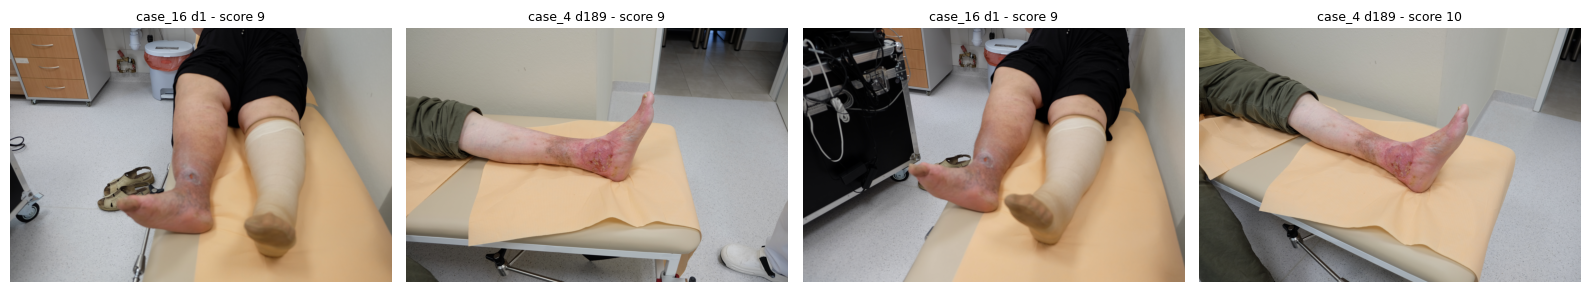

In [ ]:
# mostra visualmente as 4 fotos com pior nitidez, para confirmar se sao mesmo problematicas
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, r) in zip(axs, blur_df.head(4).iterrows()):
    row = venous[(venous["case"] == r["case"]) & (venous["day"] == r["day"]) & (venous["scene"] == r["scene"])].iloc[0]
    folder = scene_folder(row)
    photo = load_rgb(folder / "photo.jpg")
    ax.imshow(photo)
    ax.set_title(f"case_{r['case']} d{r['day']} - score {r['blur_score']:.0f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Qualidade tecnica: exposicao/iluminacao

Verifica o brilho medio de cada foto -- imagens muito escuras ou muito claras (estouradas) podem prejudicar a analise de cor do tecido.

Estatisticas de brilho medio (escala 0-255):
count    124.000000
mean     124.295014
std       23.806880
min       74.072447
25%      108.228857
50%      128.161422
75%      143.597493
max      167.353923
Name: brightness_mean, dtype: float64


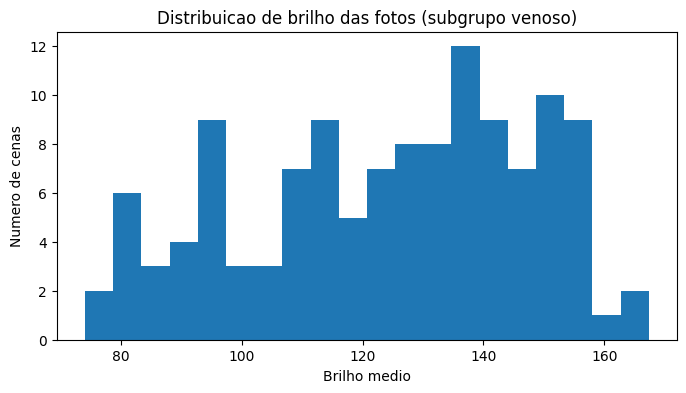

In [ ]:
brightness = []
for _, row in venous.iterrows():
    folder = scene_folder(row)
    try:
        photo_gray = load_gray(folder / "photo.jpg")
        brightness.append({
            "case": row["case"], "day": row["day"], "scene": row["scene"],
            "brightness_mean": photo_gray.mean(),
        })
    except FileNotFoundError:
        continue

bright_df = pd.DataFrame(brightness)
print("Estatisticas de brilho medio (escala 0-255):")
print(bright_df["brightness_mean"].describe())

plt.figure(figsize=(8, 4))
plt.hist(bright_df["brightness_mean"], bins=20)
plt.xlabel("Brilho medio")
plt.ylabel("Numero de cenas")
plt.title("Distribuicao de brilho das fotos (subgrupo venoso)")
plt.show()

## 9. Qualidade tecnica: consistencia de arquivos (checagem de integridade)

Percorre todas as cenas do subgrupo e verifica se os arquivos esperados realmente existem e abrem sem erro -- identifica cenas problematicas antes de qualquer analise maior.

In [ ]:
expected = ["photo.jpg", "thermal.png", "thermal.csv", "mask.png", "stereo_l.png", "stereo_r.png"]
problems = []

for _, row in venous.iterrows():
    folder = scene_folder(row)
    for fname in expected:
        fpath = folder / fname
        if not fpath.exists():
            problems.append({"case": row["case"], "day": row["day"], "scene": row["scene"],
                              "arquivo_faltante": fname})

if problems:
    print(f"Encontrados {len(problems)} arquivos faltantes:")
    print(pd.DataFrame(problems))
else:
    print("Nenhum arquivo esperado faltando no subgrupo venoso.")

Nenhum arquivo esperado faltando no subgrupo venoso.


## 10. Termografia: faixa de valores de temperatura (thermal.csv)

Confere os valores reais de temperatura (nao so a imagem colorida) para checar consistencia de calibracao entre cenas e detectar possiveis outliers.

In [ ]:
thermal_stats = []
for _, row in venous.head(20).iterrows():
    folder = scene_folder(row)
    try:
        tcsv = pd.read_csv(folder / "thermal.csv", header=None)
        arr = tcsv.values.astype(float)
        thermal_stats.append({
            "case": row["case"], "day": row["day"], "scene": row["scene"],
            "temp_min": arr.min(), "temp_max": arr.max(), "temp_mean": arr.mean(),
        })
    except Exception as e:
        thermal_stats.append({"case": row["case"], "day": row["day"], "scene": row["scene"],
                               "erro": str(e)})

thermal_stats_df = pd.DataFrame(thermal_stats)
thermal_stats_df

,case,day,scene,erro
0,1,1,1,could not convert string to float: 'min;21.0;m...
1,11,1,1,could not convert string to float: 'min;24.0;m...
2,11,1,2,could not convert string to float: 'min;24.0;m...
3,11,196,1,could not convert string to float: 'min;21.0;m...
4,11,196,2,could not convert string to float: 'min;21.0;m...
5,12,1,1,could not convert string to float: 'min;21.0;m...
6,12,1,2,could not convert string to float: 'min;23.0;m...
7,12,1,3,could not convert string to float: 'min;23.0;m...
8,12,124,1,could not convert string to float: 'min;24.0;m...
9,12,124,2,could not convert string to float: 'min;24.0;m...


## 11. Recorte da regiao da ferida (zoom usando a mascara)

Recorta a foto na area delimitada pela mascara, para inspecionar de perto a textura e cor do tecido em varios casos -- util para validar visualmente as hipoteses de biomarcadores de cor/textura.

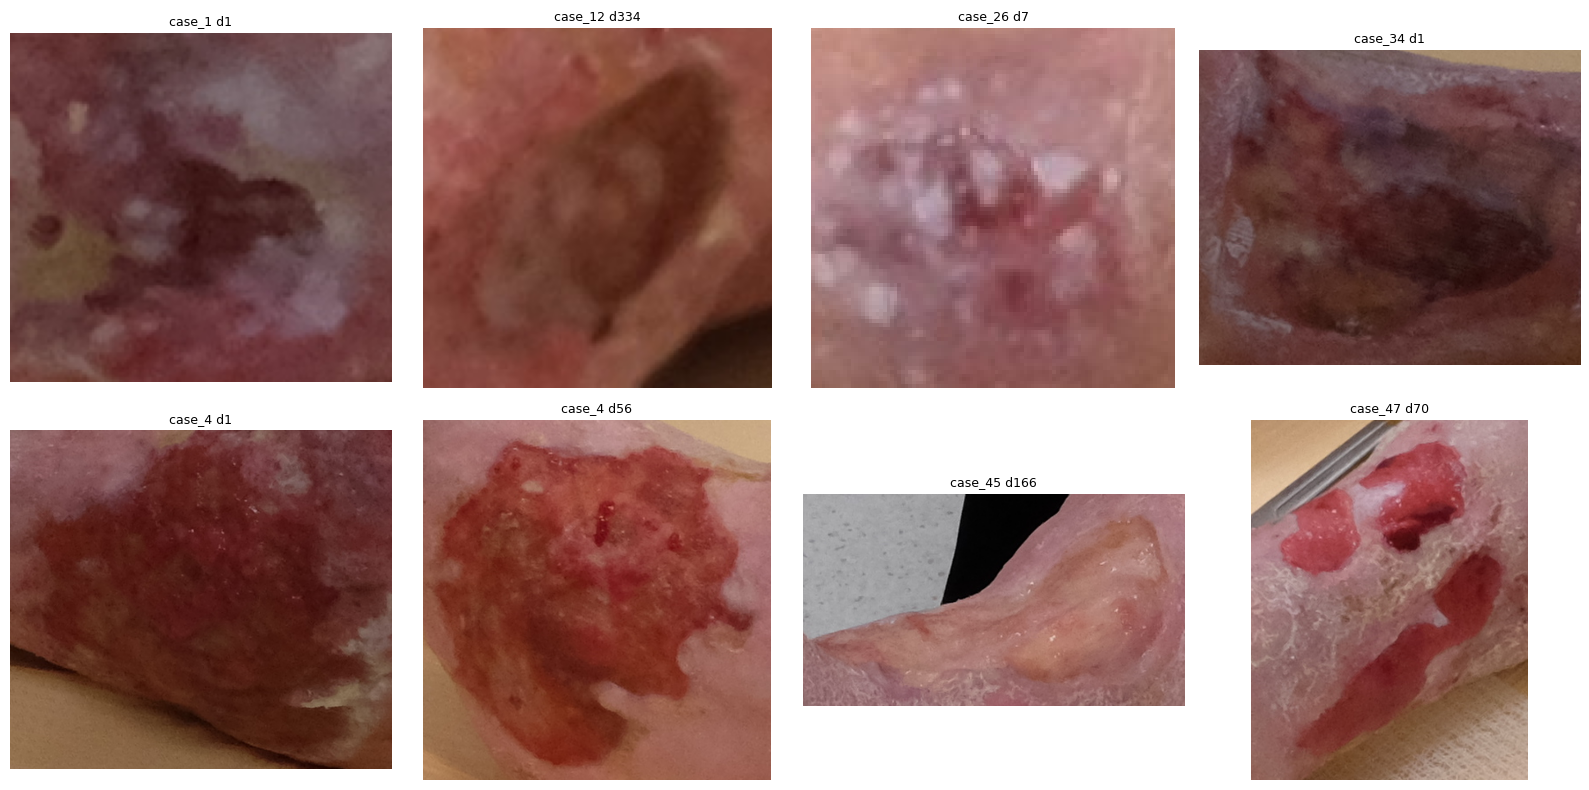

In [ ]:
def crop_to_mask(img, mask, padding=20):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return img
    x0, x1 = max(xs.min() - padding, 0), min(xs.max() + padding, img.shape[1])
    y0, y1 = max(ys.min() - padding, 0), min(ys.max() + padding, img.shape[0])
    return img[y0:y1, x0:x1]

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axs.ravel(), sample_idxs[:8]):
    row = venous.iloc[idx]
    folder = scene_folder(row)
    photo = load_rgb(folder / "photo.jpg")
    mask = load_gray(folder / "mask.png")
    crop = crop_to_mask(photo, mask)
    ax.imshow(crop)
    ax.set_title(f"case_{row['case']} d{row['day']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Par estereo: checagem visual de disparidade

Mostra as duas imagens do par estereo lado a lado para um caso, e uma versao anaglifo simples (vermelho/ciano) que ajuda a visualizar o quanto elas estao deslocadas entre si -- uma checagem rapida de que o par estereo faz sentido fisicamente.

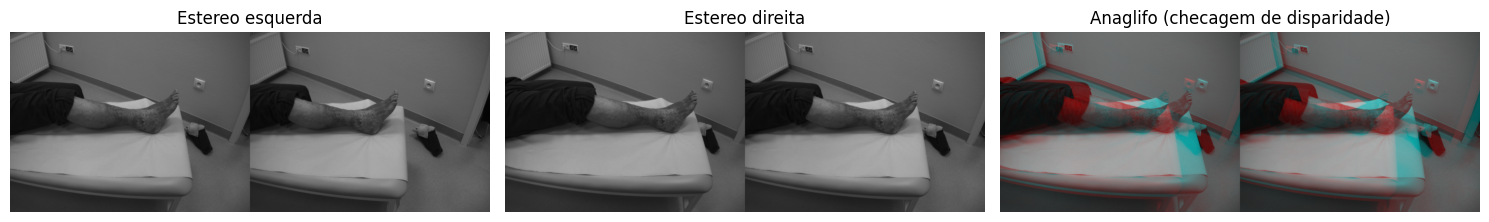

In [ ]:
row = venous.iloc[0]
folder = scene_folder(row)
left = load_rgb(folder / "stereo_l.png")
right = load_rgb(folder / "stereo_r.png")

anaglyph = np.zeros_like(left)
anaglyph[..., 0] = cv2.cvtColor(left, cv2.COLOR_RGB2GRAY)
anaglyph[..., 1] = cv2.cvtColor(right, cv2.COLOR_RGB2GRAY)
anaglyph[..., 2] = cv2.cvtColor(right, cv2.COLOR_RGB2GRAY)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(left); axs[0].set_title("Estereo esquerda")
axs[1].imshow(right); axs[1].set_title("Estereo direita")
axs[2].imshow(anaglyph); axs[2].set_title("Anaglifo (checagem de disparidade)")
for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()